# Python Visual Analysis (Post-SQL)

This notebook presents **select visualizations** derived from the cleaned datasets
and SQL outputs.

The purpose of these visuals is to:
- Validate SQL insights
- Communicate business trends
- Support decision-making

All heavy analytics are performed in **MySQL**.
Python is used here strictly for **visual storytelling**.

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Path handling (OS-independent)
from pathlib import Path

In [3]:
# Styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Project root (notebook is inside /notebooks)
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

print("Project root:", PROJECT_ROOT)
print("Data directory exists:", DATA_DIR.exists())
print("Output directory exists:", OUTPUT_DIR.exists())

Project root: C:\Users\NIVAS\Desktop\Jobaaj\ecommerce-sql-python-analysis
Data directory exists: True
Output directory exists: True


In [4]:
# Load SQL output / prepared datasets

monthly_revenue = pd.read_csv(OUTPUT_DIR / "monthly_revenue.csv")
order_level_data = pd.read_csv(OUTPUT_DIR / "order_level_data.csv")
product_price_vs_purchase = pd.read_csv(OUTPUT_DIR / "product_price_vs_purchase.csv")

# Quick sanity check
display(monthly_revenue.head())
display(order_level_data.head())
display(product_price_vs_purchase.head())


,year,month,monthly_revenue
0,2016,9,354.75
1,2016,10,56808.84
2,2016,12,19.62
3,2017,1,137188.49
4,2017,2,286280.62


,order_id,customer_id,order_value
0,00125cb692d04887809806618a2a145f,8afb90a97ee661103014329b1bcea1a2,135.41
1,00571ded73b3c061925584feab0db425,3c628393675b42c6b5ef89461f68ecef,389.82
2,006dd93155bc2abd844cc5eed3a0fe7f,1b9506de3da8fd318853195b13fb2dda,57.68
3,00946f674d880be1f188abc10ad7cf46,9583b047c90d4aa1c5c68b4065ba7f4e,232.72
4,00a0116ff15ff973ea16bee881208ae7,89a187407adfc8a32a4d6233a6a237d8,194.12


,product_id,avg_price,purchase_count
0,4244733e06e7ecb4970a6e2683c13e61,59.233333,9
1,e5f2d52b802189ee658865ca93d83a8f,239.900000,1
2,c777355d18b72b67abbeef9df44fd0fd,199.000000,3
3,7634da152a4610f1595efa32f14722fc,12.990000,2
4,ac6c3623068f30de03045865e4e10089,202.400000,12


## Monthly Revenue Trend

This visualization validates the monthly revenue trend calculated in SQL.
It highlights revenue growth patterns and seasonality over time.

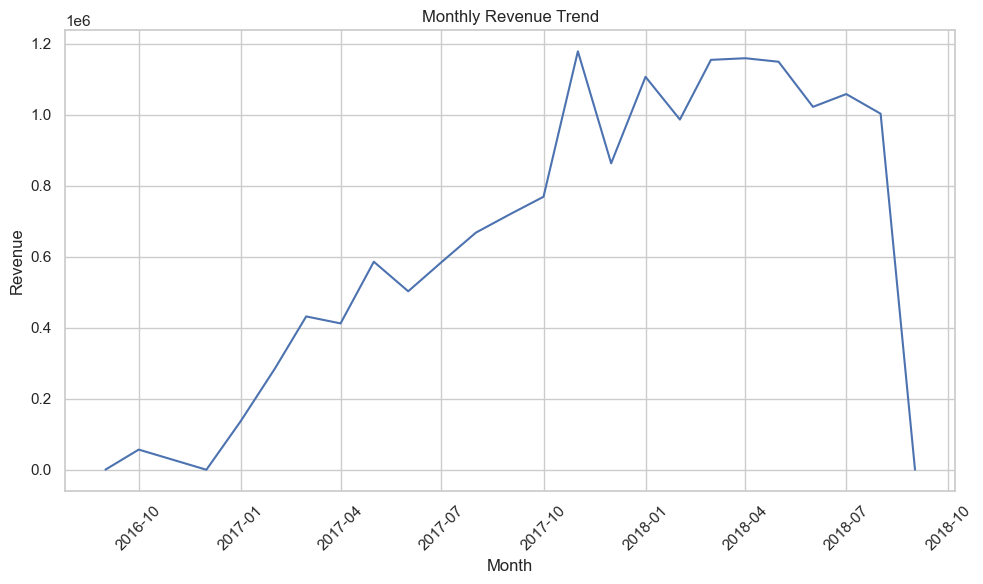

In [6]:
# Monthly Revenue Trend

# Create a datetime column for proper ordering
monthly_revenue["date"] = pd.to_datetime(
    monthly_revenue["year"].astype(str) + "-" +
    monthly_revenue["month"].astype(str) + "-01"
)

monthly_revenue = monthly_revenue.sort_values("date")

plt.figure()
plt.plot(monthly_revenue["date"], monthly_revenue["monthly_revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Customers by Order Value

This visualization highlights the top customers based on total order value.
It helps identify high-value customers who contribute most to overall revenue.


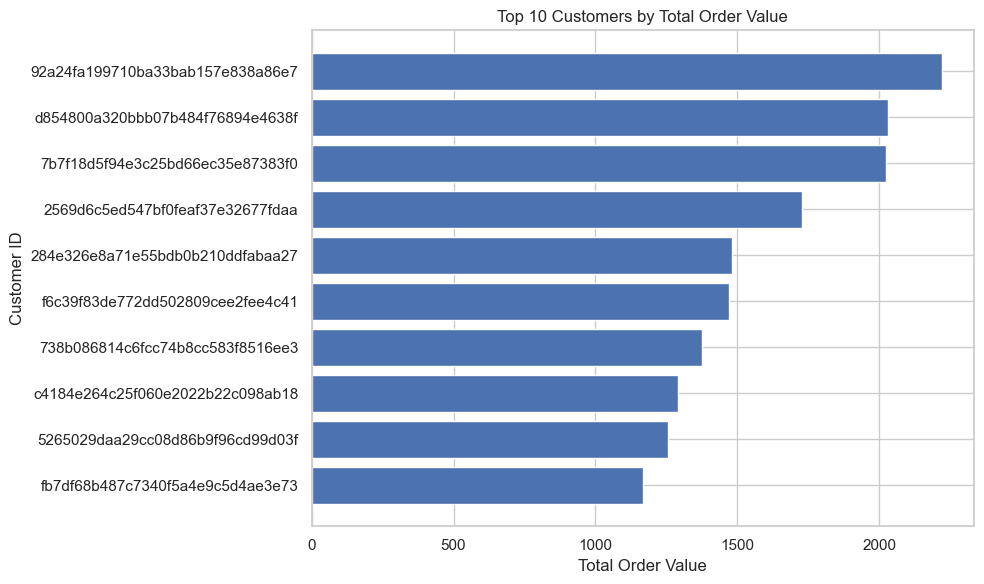

In [7]:
# Top 10 Customers by Order Value

top_customers = (
    order_level_data
    .groupby("customer_id", as_index=False)["order_value"]
    .sum()
    .sort_values("order_value", ascending=False)
    .head(10)
)

plt.figure()
plt.barh(top_customers["customer_id"], top_customers["order_value"])
plt.title("Top 10 Customers by Total Order Value")
plt.xlabel("Total Order Value")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()  # Highest value on top
plt.tight_layout()
plt.show()


## Distribution of Order Values

This histogram shows how order values are distributed across all transactions.
It helps identify whether the business relies on many small orders or fewer high-value purchases.


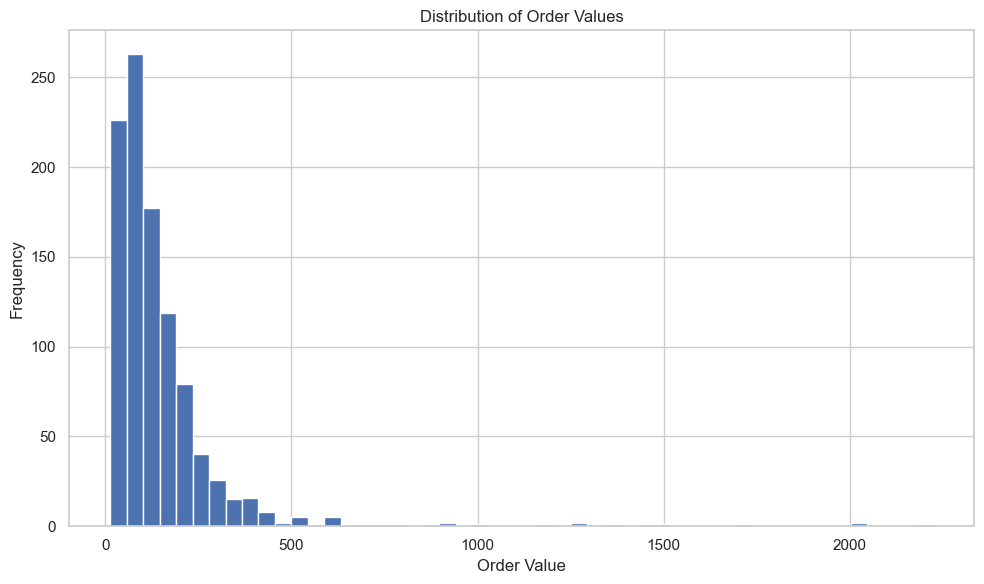

In [9]:
# Distribution of Order Values

plt.figure()
plt.hist(order_level_data["order_value"], bins=50)
plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Product Price vs Purchase Frequency

This scatter plot highlights the relationship between average product price and purchase frequency.
It helps identify whether high-priced products sell less frequently and where volume-driven revenue exists.

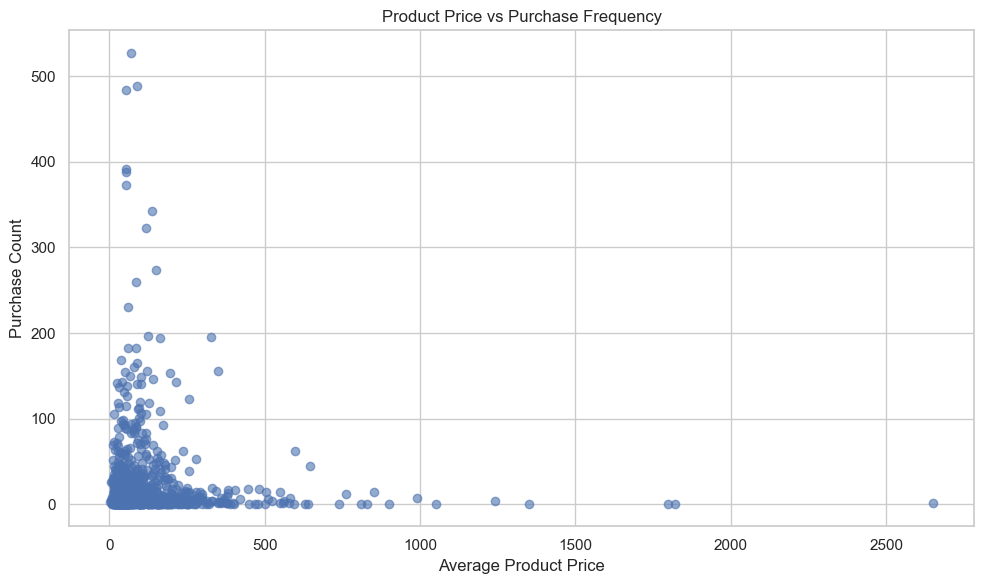

In [10]:
# Product Price vs Purchase Frequency

plt.figure()
plt.scatter(
    product_price_vs_purchase["avg_price"],
    product_price_vs_purchase["purchase_count"],
    alpha=0.6
)

plt.title("Product Price vs Purchase Frequency")
plt.xlabel("Average Product Price")
plt.ylabel("Purchase Count")
plt.tight_layout()
plt.show()

In [11]:
# Aggregate monthly revenue to yearly revenue
yearly_revenue = (
    monthly_revenue
    .groupby("year", as_index=False)["monthly_revenue"]
    .sum()
)

display(yearly_revenue)

,year,monthly_revenue
0,2016,57183.21
1,2017,7142672.43
2,2018,8643697.60


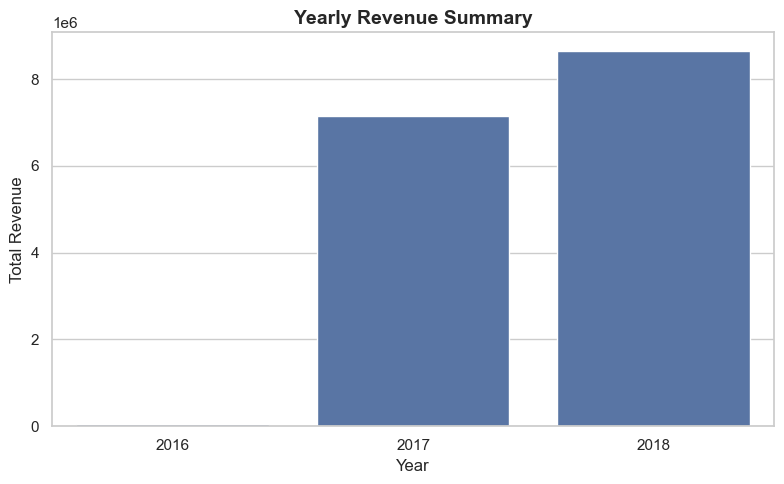

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=yearly_revenue,
    x="year",
    y="monthly_revenue"
)

plt.title("Yearly Revenue Summary", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

### Insight: Yearly Revenue Performance

- Revenue shows strong growth from 2016 to 2018, indicating increasing platform adoption and order volume.
- The year-over-year increase validates trends observed in the monthly revenue analysis.
- This high-level view is useful for executive reporting and long-term strategic planning.

### Key Insight

- Purchase frequency declines as product price increases, indicating a clear price–demand tradeoff.
- Low-priced products are volume drivers, while high-priced products are niche with lower demand.
- This insight supports differentiated pricing and inventory strategies for revenue optimization.
